# 03 — Model Training & Evaluation
### AI-Generated Bengali Handwritten Signature Detection

Trains and compares three models on the preprocessed, writer-split dataset produced by
Notebook 02 (`dataset/metadata_processed.csv` + `dataset/normalization_stats.csv` +
`processed_dataset/`):

1. **Custom CNN** (trained from scratch)
2. **ResNet18** (ImageNet-pretrained, transfer learning)
3. **EfficientNet-B0** (ImageNet-pretrained, transfer learning)

Then covers:
- Full evaluation (accuracy, precision, recall, F1, ROC-AUC, confusion matrix) — overall and
  broken down **per generator** (Genuine / Gemini / QN / GPT — whichever are present; this
  notebook doesn't hardcode which generators exist, so adding QN data later needs no edits)
- A **cross-generator generalization** experiment (train holding one generator out, test on it)
- **Grad-CAM** explainability on the best-performing model

**Self-contained:** this version defines `SignatureDataset` / transforms / metadata loading
directly in this notebook rather than importing a `data_utils.py` that was never produced by
Notebook 02 — this is a fix from the previous version, which would fail with
`ModuleNotFoundError: No module named 'data_utils'`.

**Hardware:** written for a 2GB-VRAM laptop GPU (MX350) per the project's hardware notes —
`batch_size=8`, `num_workers=0` (2 previously caused DataLoader issues on Windows/Jupyter).

## 1. Setup

In [3]:
import copy
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms as T
from PIL import Image

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

DATASET_ROOT = Path("../dataset")
CKPT_DIR = Path("checkpoints")
CKPT_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

# MX350 / 2GB VRAM settings -- raise BATCH_SIZE if you have more headroom, but keep
# num_workers at 0 (num_workers=2 previously caused DataLoader problems in this project).
BATCH_SIZE = 8
NUM_WORKERS = 0


Using device: cuda
GPU: NVIDIA GeForce MX350


In [4]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

PyTorch: 2.5.1+cu118
CUDA available: True
CUDA version: 11.8
GPU count: 1


## 2. Data loading

Reads the outputs of Notebook 02 directly — no external module required. `SignatureDataset`
accepts an optional `generators` filter (a list of generator names, e.g. `["Human","Gemini"]`)
so the same class covers the overall experiment and the per-generator / cross-generator ones
below without duplicating loading logic.

In [5]:
class SignatureDataset(Dataset):
    '''Reads preprocessed (RGB, 224x224) images listed in metadata_processed.csv.

    Parameters
    ----------
    metadata_df : DataFrame with at least [filepath, label, generator, split] columns.
    split : "train" | "val" | "test"
    transform : torchvision transform applied to the loaded PIL image.
    generators : optional list restricting rows to specific generator(s), e.g.
        ["Human", "Gemini"] for a Human-vs-Gemini-only experiment (master note Experiment 2).
        "Human" is always the genuine/label-0 rows in this project's metadata convention.
    '''

    def __init__(self, metadata_df, split, transform=None, generators=None):
        d = metadata_df[metadata_df["split"] == split]
        if generators is not None:
            d = d[d["generator"].isin(generators)]
        self.df = d.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, int(row["label"])


def load_metadata(dataset_root: Path):
    meta_path = dataset_root / "metadata_processed.csv"
    norm_path = dataset_root / "normalization_stats.csv"
    assert meta_path.exists(), f"{meta_path} not found -- run Notebook 02 first."
    assert norm_path.exists(), f"{norm_path} not found -- run Notebook 02 first."

    df = pd.read_csv(meta_path)
    norm = pd.read_csv(norm_path).iloc[0]
    mean = [norm["mean_r"], norm["mean_g"], norm["mean_b"]]
    std = [norm["std_r"], norm["std_g"], norm["std_b"]]
    return df, mean, std


def build_transforms(mean, std):
    train_tf = T.Compose([
        T.RandomAffine(degrees=5, translate=(0.03, 0.03), scale=(0.97, 1.03), fill=255),
        T.ColorJitter(brightness=0.1, contrast=0.1),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])
    eval_tf = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])
    return train_tf, eval_tf


metadata_df, NORM_MEAN, NORM_STD = load_metadata(DATASET_ROOT)
train_transform, eval_transform = build_transforms(NORM_MEAN, NORM_STD)

GENERATORS_PRESENT = sorted(metadata_df["generator"].unique().tolist())
print(f"Generators present in metadata: {GENERATORS_PRESENT}")

train_ds = SignatureDataset(metadata_df, "train", transform=train_transform)
val_ds = SignatureDataset(metadata_df, "val", transform=eval_transform)
test_ds = SignatureDataset(metadata_df, "test", transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

# Class weights -- computed from whatever the actual train-split counts are (don't hardcode
# a specific genuine/AI ratio, since dataset counts change as generators are added).
train_labels = metadata_df.loc[metadata_df["split"] == "train", "label"].values
class_counts = np.bincount(train_labels, minlength=2)
class_weights = torch.tensor(len(train_labels) / (2.0 * class_counts), dtype=torch.float32).to(DEVICE)
print(f"Train class counts: {class_counts.tolist()}, class weights: {class_weights.tolist()}")


Generators present in metadata: ['GPT', 'Gemini', 'Human', 'QN']
train: 1461, val: 308, test: 265
Train class counts: [695, 766], class weights: [1.0510791540145874, 0.9536553621292114]


## 3. Model definitions

In [6]:
class CustomCNN(nn.Module):
    '''Lightweight from-scratch baseline -- establishes whether the dataset carries enough
    visual signal before relying on transfer learning.'''

    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),    # 224->112
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),   # 112->56
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 56->28
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),# 28->14
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def build_resnet18(num_classes=2, freeze_backbone=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def build_efficientnet_b0(num_classes=2, freeze_backbone=True):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


MODEL_BUILDERS = {
    "custom_cnn": lambda: CustomCNN(),
    "resnet18": lambda: build_resnet18(freeze_backbone=True),
    "efficientnet_b0": lambda: build_efficientnet_b0(freeze_backbone=True),
}


## 4. Training loop (shared across models, fully resumable)

Every checkpoint (`{name}_latest.pt`, saved every epoch, and `{name}_best.pt`, saved on
every validation-loss improvement) stores `epoch`, `model_state`, `optimizer_state`,
`scheduler_state`, `best_val_loss`, `epochs_no_improve`, and `history` — so a crash never
loses training progress, and `resume=True` picks up exactly where it left off, including
re-applying the fine-tune unfreeze/LR-drop if training had already passed that epoch.

In [7]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            all_preds.extend(outputs.argmax(dim=1).detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


def train_model(model_name, train_loader, val_loader, num_epochs=30, lr=1e-3, patience=7,
                 fine_tune_after=None, fine_tune_lr=1e-5, resume=False,
                 ckpt_tag=None):
    '''Train (or resume) a model with early stopping + full checkpointing.

    ckpt_tag lets you namespace checkpoints per-experiment (e.g. "exp2_human_vs_gemini")
    so different experiments' checkpoints don't overwrite each other.
    '''
    tag = ckpt_tag or model_name
    latest_ckpt_path = CKPT_DIR / f"{tag}_latest.pt"
    best_ckpt_path = CKPT_DIR / f"{tag}_best.pt"

    model = MODEL_BUILDERS[model_name]().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    best_val_loss = float("inf")
    epochs_no_improve = 0
    start_epoch = 1
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    if resume and latest_ckpt_path.exists():
        print(f"[{tag}] Loading checkpoint: {latest_ckpt_path}")
        checkpoint = torch.load(latest_ckpt_path, map_location=DEVICE)

        # If we're resuming past the fine-tune switch, unfreeze + rebuild the optimizer
        # BEFORE loading optimizer state, so shapes/param groups match.
        already_finetuned = (fine_tune_after is not None
                              and checkpoint["epoch"] + 1 > fine_tune_after
                              and model_name != "custom_cnn")
        if already_finetuned:
            for p in model.parameters():
                p.requires_grad = True
            optimizer = torch.optim.Adam(model.parameters(), lr=fine_tune_lr)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        scheduler.load_state_dict(checkpoint["scheduler_state"])
        start_epoch = checkpoint["epoch"] + 1
        best_val_loss = checkpoint["best_val_loss"]
        epochs_no_improve = checkpoint["epochs_no_improve"]
        history = checkpoint["history"]
        print(f"[{tag}] Resuming from epoch {start_epoch}")
    elif resume:
        print(f"[{tag}] resume=True but no checkpoint found -- starting fresh.")

    for epoch in range(start_epoch, num_epochs + 1):
        if (fine_tune_after is not None and epoch == fine_tune_after + 1
                and model_name != "custom_cnn"):
            print(f"[{tag}] epoch {epoch}: unfreezing backbone, LR -> {fine_tune_lr}")
            for p in model.parameters():
                p.requires_grad = True
            optimizer = torch.optim.Adam(model.parameters(), lr=fine_tune_lr)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{tag}] epoch {epoch:02d}/{num_epochs} "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}")

        improved = val_loss < best_val_loss - 1e-4
        if improved:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({
                "epoch": epoch, "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(), "scheduler_state": scheduler.state_dict(),
                "best_val_loss": best_val_loss, "epochs_no_improve": epochs_no_improve,
                "history": history,
            }, best_ckpt_path)
        else:
            epochs_no_improve += 1

        # Always save "latest" -- a crash should never lose progress.
        torch.save({
            "epoch": epoch, "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(), "scheduler_state": scheduler.state_dict(),
            "best_val_loss": best_val_loss, "epochs_no_improve": epochs_no_improve,
            "history": history,
        }, latest_ckpt_path)

        if epochs_no_improve >= patience:
            print(f"[{tag}] Early stopping at epoch {epoch} (no improvement for {patience} epochs).")
            break

    # Return the model loaded with its BEST weights (not necessarily the last epoch's).
    best_ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(best_ckpt["model_state"])
    return model, history


## 5. Train all three models (Experiment 1: Human vs. AI, all generators; Experiment 6:
Custom CNN vs. ResNet18 vs. EfficientNet-B0)

Per the project's training plan: 30 epochs, patience 7; ResNet18/EfficientNet-B0 start with a
frozen backbone and fine-tune at a lower LR after epoch 10. Set `resume=True` below to
continue an interrupted run instead of starting over.

In [8]:
trained_models = {}
histories = {}

trained_models["custom_cnn"], histories["custom_cnn"] = train_model(
    "custom_cnn", train_loader, val_loader,
    num_epochs=30, lr=1e-3, patience=7, resume=False,
)


[custom_cnn] epoch 01/30 train_loss=0.6390 train_acc=0.611 val_loss=0.4588 val_acc=0.795
[custom_cnn] epoch 02/30 train_loss=0.5035 train_acc=0.746 val_loss=0.2508 val_acc=0.922
[custom_cnn] epoch 03/30 train_loss=0.3990 train_acc=0.825 val_loss=0.4842 val_acc=0.714
[custom_cnn] epoch 04/30 train_loss=0.3487 train_acc=0.840 val_loss=0.5402 val_acc=0.769
[custom_cnn] epoch 05/30 train_loss=0.3228 train_acc=0.871 val_loss=0.3724 val_acc=0.818
[custom_cnn] epoch 06/30 train_loss=0.3073 train_acc=0.869 val_loss=0.4074 val_acc=0.805
[custom_cnn] epoch 07/30 train_loss=0.2681 train_acc=0.889 val_loss=0.0824 val_acc=0.974
[custom_cnn] epoch 08/30 train_loss=0.2900 train_acc=0.890 val_loss=0.9926 val_acc=0.630
[custom_cnn] epoch 09/30 train_loss=0.2662 train_acc=0.895 val_loss=0.1049 val_acc=0.977
[custom_cnn] epoch 10/30 train_loss=0.2421 train_acc=0.904 val_loss=0.1674 val_acc=0.938
[custom_cnn] epoch 11/30 train_loss=0.2372 train_acc=0.899 val_loss=0.9500 val_acc=0.633
[custom_cnn] epoch 12

In [9]:
trained_models["resnet18"], histories["resnet18"] = train_model(
    "resnet18", train_loader, val_loader,
    num_epochs=30, lr=1e-3, patience=7, fine_tune_after=10, fine_tune_lr=1e-5, resume=False,
)


[resnet18] epoch 01/30 train_loss=0.5498 train_acc=0.707 val_loss=0.5834 val_acc=0.672
[resnet18] epoch 02/30 train_loss=0.4792 train_acc=0.754 val_loss=0.3873 val_acc=0.805
[resnet18] epoch 03/30 train_loss=0.4135 train_acc=0.810 val_loss=0.3949 val_acc=0.792
[resnet18] epoch 04/30 train_loss=0.4233 train_acc=0.811 val_loss=0.4258 val_acc=0.782
[resnet18] epoch 05/30 train_loss=0.4241 train_acc=0.807 val_loss=0.5401 val_acc=0.731
[resnet18] epoch 06/30 train_loss=0.3959 train_acc=0.836 val_loss=0.3314 val_acc=0.847
[resnet18] epoch 07/30 train_loss=0.3958 train_acc=0.838 val_loss=0.3515 val_acc=0.841
[resnet18] epoch 08/30 train_loss=0.3873 train_acc=0.828 val_loss=0.3660 val_acc=0.805
[resnet18] epoch 09/30 train_loss=0.3929 train_acc=0.824 val_loss=0.3772 val_acc=0.812
[resnet18] epoch 10/30 train_loss=0.3604 train_acc=0.838 val_loss=0.4961 val_acc=0.753
[resnet18] epoch 11: unfreezing backbone, LR -> 1e-05
[resnet18] epoch 11/30 train_loss=0.3518 train_acc=0.836 val_loss=0.3037 val

In [10]:
trained_models["efficientnet_b0"], histories["efficientnet_b0"] = train_model(
    "efficientnet_b0", train_loader, val_loader,
    num_epochs=30, lr=1e-3, patience=7, fine_tune_after=10, fine_tune_lr=1e-5, resume=False,
)


[efficientnet_b0] epoch 01/30 train_loss=0.5581 train_acc=0.695 val_loss=0.3675 val_acc=0.838
[efficientnet_b0] epoch 02/30 train_loss=0.5104 train_acc=0.739 val_loss=0.3286 val_acc=0.880
[efficientnet_b0] epoch 03/30 train_loss=0.4745 train_acc=0.773 val_loss=0.3512 val_acc=0.854
[efficientnet_b0] epoch 04/30 train_loss=0.4623 train_acc=0.765 val_loss=0.2820 val_acc=0.903
[efficientnet_b0] epoch 05/30 train_loss=0.4656 train_acc=0.777 val_loss=0.2577 val_acc=0.916
[efficientnet_b0] epoch 06/30 train_loss=0.4574 train_acc=0.779 val_loss=0.3022 val_acc=0.880
[efficientnet_b0] epoch 07/30 train_loss=0.4539 train_acc=0.785 val_loss=0.3139 val_acc=0.844
[efficientnet_b0] epoch 08/30 train_loss=0.4510 train_acc=0.775 val_loss=0.3756 val_acc=0.825
[efficientnet_b0] epoch 09/30 train_loss=0.4646 train_acc=0.786 val_loss=0.2937 val_acc=0.883
[efficientnet_b0] epoch 10/30 train_loss=0.4351 train_acc=0.781 val_loss=0.3244 val_acc=0.854
[efficientnet_b0] epoch 11: unfreezing backbone, LR -> 1e-05

### Training curves

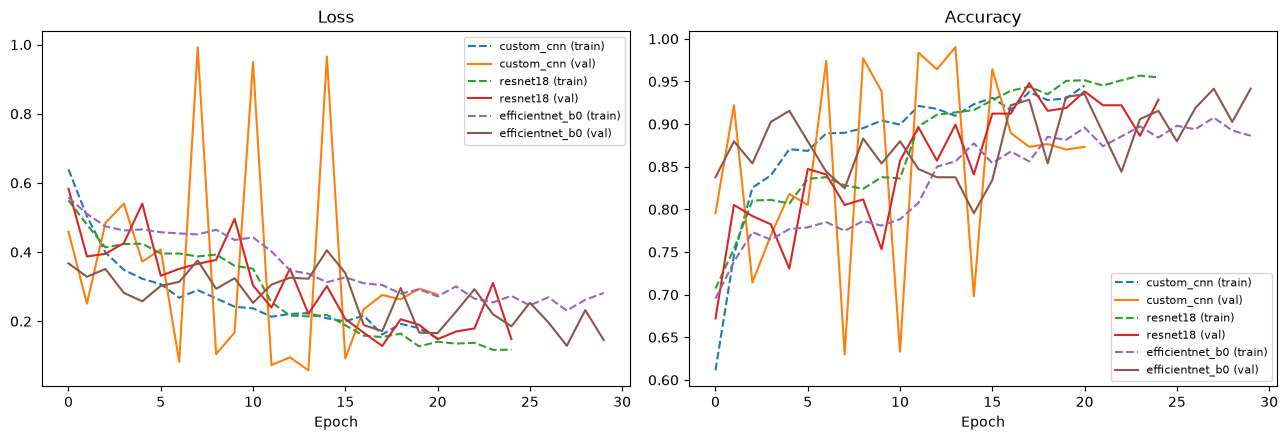

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, h in histories.items():
    axes[0].plot(h["train_loss"], label=f"{name} (train)", linestyle="--")
    axes[0].plot(h["val_loss"], label=f"{name} (val)")
    axes[1].plot(h["train_acc"], label=f"{name} (train)", linestyle="--")
    axes[1].plot(h["val_acc"], label=f"{name} (val)")

axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8)
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves" / "exp1_all_models.png", dpi=150) if (RESULTS_DIR / "training_curves").exists() else None
plt.show()


## 6. Evaluation — overall and per-generator

In [12]:
def evaluate_model(model, loader):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    all_probs, all_preds, all_labels = np.array(all_probs), np.array(all_preds), np.array(all_labels)
    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds, labels=[0, 1]).ravel()

    metrics = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "roc_auc": roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else float("nan"),
        "human_recall": tn / (tn + fp) if (tn + fp) > 0 else float("nan"),
        "ai_recall": tp / (tp + fn) if (tp + fn) > 0 else float("nan"),
    }
    return metrics, all_preds, all_probs, all_labels


results_summary = []
for name, model in trained_models.items():
    metrics, preds, probs, labels = evaluate_model(model, test_loader)
    metrics["model"] = name
    results_summary.append(metrics)

results_df = pd.DataFrame(results_summary).set_index("model")[
    ["accuracy", "precision", "recall", "f1", "roc_auc", "human_recall", "ai_recall"]]
results_df


,accuracy,precision,recall,f1,roc_auc,human_recall,ai_recall
model,,,,,,,
custom_cnn,0.969811,0.982143,0.948276,0.964912,0.996818,0.986577,0.948276
resnet18,0.932075,0.865672,1.000000,0.928000,0.998091,0.879195,1.000000
efficientnet_b0,0.905660,0.832117,0.982759,0.901186,0.984436,0.845638,0.982759


### Per-generator breakdown

Loops over **whatever generators are actually present** in the test split (`Human` plus
Gemini/QN/GPT — any subset), so adding QN data later needs no changes here. Per the master
note, don't rely on the aggregate row alone: a model can look strong overall while quietly
failing on one generator.

In [13]:
def evaluate_by_generator(model, metadata_df, transform):
    rows = []
    test_generators = metadata_df.loc[metadata_df["split"] == "test", "generator"].unique()
    ai_generators = [g for g in test_generators if g != "Human"]

    for gen in ai_generators:
        sub_ds = SignatureDataset(metadata_df, "test", transform=transform, generators=["Human", gen])
        if len(sub_ds) == 0:
            continue
        sub_loader = DataLoader(sub_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        metrics, _, _, _ = evaluate_model(model, sub_loader)
        metrics["generator"] = gen
        metrics["n"] = len(sub_ds)
        rows.append(metrics)

    cols = ["generator", "n", "accuracy", "precision", "recall", "f1", "roc_auc", "human_recall", "ai_recall"]
    return pd.DataFrame(rows)[cols] if rows else pd.DataFrame(columns=cols)


generator_results = {}
for name, model in trained_models.items():
    print(f"--- {name}: per-generator test metrics (Human vs. each generator) ---")
    gen_df = evaluate_by_generator(model, metadata_df, eval_transform)
    generator_results[name] = gen_df
    display(gen_df.round(4))


--- custom_cnn: per-generator test metrics (Human vs. each generator) ---


,generator,n,accuracy,precision,recall,f1,roc_auc,human_recall,ai_recall
0,Gemini,176,0.9545,0.9130,0.7778,0.8400,0.9863,0.9866,0.7778
1,QN,209,0.9904,0.9677,1.0000,0.9836,1.0000,0.9866,1.0000
2,GPT,178,0.9888,0.9355,1.0000,0.9667,1.0000,0.9866,1.0000


--- resnet18: per-generator test metrics (Human vs. each generator) ---


,generator,n,accuracy,precision,recall,f1,roc_auc,human_recall,ai_recall
0,Gemini,176,0.8977,0.6000,1.0,0.7500,0.9928,0.8792,1.0
1,QN,209,0.9139,0.7692,1.0,0.8696,0.9996,0.8792,1.0
2,GPT,178,0.8989,0.6170,1.0,0.7632,1.0000,0.8792,1.0


--- efficientnet_b0: per-generator test metrics (Human vs. each generator) ---


,generator,n,accuracy,precision,recall,f1,roc_auc,human_recall,ai_recall
0,Gemini,176,0.8580,0.5208,0.9259,0.6667,0.9575,0.8456,0.9259
1,QN,209,0.8900,0.7229,1.0000,0.8392,0.9894,0.8456,1.0000
2,GPT,178,0.8708,0.5577,1.0000,0.7160,0.9993,0.8456,1.0000


This table is exactly the "generator analysis" table from the master research note
(Section 11: Human vs Gemini / Human vs QN / Human vs GPT, with accuracy/precision/recall/F1/
ROC-AUC) — reused per-model here instead of being computed only once.

### Confusion matrices and ROC curves

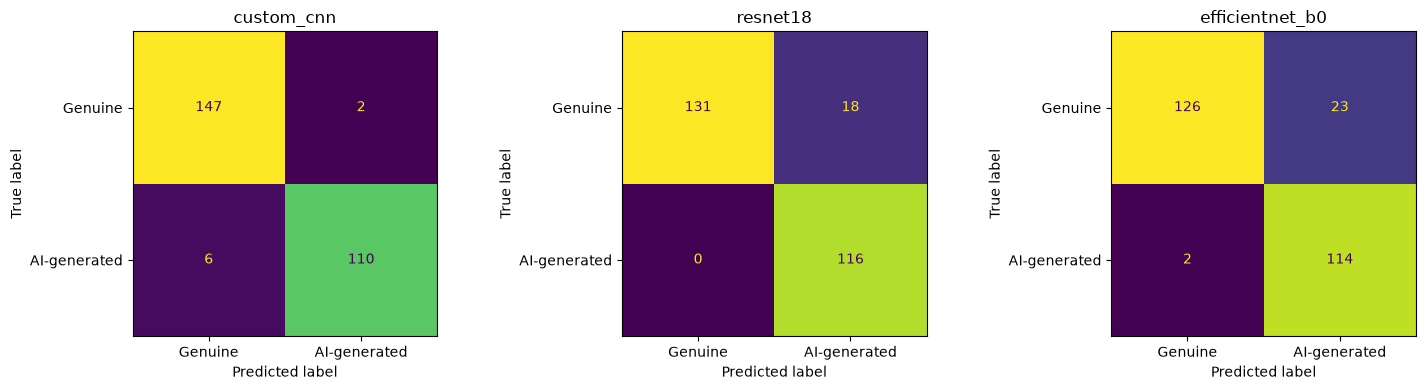

In [14]:
fig, axes = plt.subplots(1, len(trained_models), figsize=(5 * len(trained_models), 4))
if len(trained_models) == 1:
    axes = [axes]
for ax, (name, model) in zip(axes, trained_models.items()):
    _, preds, _, labels = evaluate_model(model, test_loader)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["Genuine", "AI-generated"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


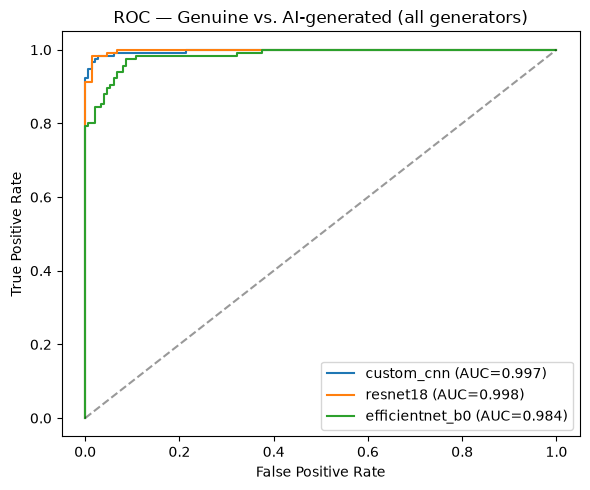

In [15]:
plt.figure(figsize=(6, 5))
for name, model in trained_models.items():
    _, _, probs, labels = evaluate_model(model, test_loader)
    if len(set(labels)) > 1:
        fpr, tpr, _ = roc_curve(labels, probs)
        auc = roc_auc_score(labels, probs)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC — Genuine vs. AI-generated (all generators)")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Cross-generator generalization experiment

Trains on all generators **except** one held-out generator, then evaluates on
`Human + held_out_generator` test samples. Strong held-out performance suggests the model
learned generator-agnostic AI-signature characteristics rather than artifacts specific to one
generator — this is the reference-based-vs-no-reference question from the master note
(Section 12), generalized to run against **any** generator present, not just GPT.

In [16]:
def cross_generator_experiment(held_out_generator, model_name="resnet18", num_epochs=20):
    seen_generators = [g for g in GENERATORS_PRESENT if g != held_out_generator]
    print(f"Training on {seen_generators}, holding out '{held_out_generator}' for testing.")

    cg_train_ds = SignatureDataset(metadata_df, "train", transform=train_transform, generators=seen_generators)
    cg_val_ds = SignatureDataset(metadata_df, "val", transform=eval_transform, generators=seen_generators)
    cg_heldout_ds = SignatureDataset(metadata_df, "test", transform=eval_transform,
                                      generators=["Human", held_out_generator])

    if len(cg_train_ds) == 0 or len(cg_val_ds) == 0:
        print(f"  Not enough data to train with '{held_out_generator}' held out -- skipping.")
        return None

    cg_train_loader = DataLoader(cg_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    cg_val_loader = DataLoader(cg_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = MODEL_BUILDERS[model_name]().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-3)

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = run_epoch(model, cg_train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, cg_val_loader, criterion, optimizer=None)
        if epoch % 5 == 0 or epoch == num_epochs:
            print(f"  epoch {epoch}: train_acc={train_acc:.3f} val_acc={val_acc:.3f}")

    if len(cg_heldout_ds) == 0:
        print(f"  Held-out ('{held_out_generator}') test set is empty -- skipping evaluation.")
        return None

    heldout_loader = DataLoader(cg_heldout_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    metrics, _, _, _ = evaluate_model(model, heldout_loader)
    print(f"  Held-out ('{held_out_generator}') test metrics: {metrics}")
    return metrics


cross_gen_results = {}
for gen in [g for g in GENERATORS_PRESENT if g != "Human"]:
    cross_gen_results[gen] = cross_generator_experiment(held_out_generator=gen, model_name="resnet18")


Training on ['Gemini', 'Human', 'QN'], holding out 'GPT' for testing.
  epoch 5: train_acc=0.824 val_acc=0.709
  epoch 10: train_acc=0.817 val_acc=0.813
  epoch 15: train_acc=0.846 val_acc=0.781
  epoch 20: train_acc=0.834 val_acc=0.863
  Held-out ('GPT') test metrics: {'accuracy': 0.6966292134831461, 'precision': 0.1951219512195122, 'recall': 0.27586206896551724, 'f1': 0.22857142857142856, 'roc_auc': 0.5665355241842167, 'human_recall': np.float64(0.7785234899328859), 'ai_recall': np.float64(0.27586206896551724)}
Training on ['GPT', 'Human', 'QN'], holding out 'Gemini' for testing.
  epoch 5: train_acc=0.943 val_acc=0.975
  epoch 10: train_acc=0.932 val_acc=0.975
  epoch 15: train_acc=0.929 val_acc=0.992
  epoch 20: train_acc=0.938 val_acc=0.979
  Held-out ('Gemini') test metrics: {'accuracy': 0.8409090909090909, 'precision': 0.3333333333333333, 'recall': 0.037037037037037035, 'f1': 0.06666666666666667, 'roc_auc': 0.738255033557047, 'human_recall': np.float64(0.9865771812080537), 'ai_r

**Interpreting this experiment:** if held-out accuracy/F1 for a generator is close to
that generator's in-distribution metrics from Section 6, the model generalizes across
generators. A large drop suggests it's latching onto generator-specific artifacts — still a
scientifically valid finding per the master note (don't claim one AI model is universally
better/worse at evading detection; phrase conclusions around this specific generation setup).

## 8. Explainability — Grad-CAM

In [17]:
def get_last_conv_layer(model, model_name):
    if model_name == "custom_cnn":
        return model.features[-4]  # last Conv2d before the final pool in the block
    elif model_name == "resnet18":
        return model.layer4[-1]
    elif model_name == "efficientnet_b0":
        return model.features[-1]
    raise ValueError(model_name)


class GradCAM:
    '''Minimal Grad-CAM implementation (no external deps beyond torch).'''

    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


In [18]:
# Pick the best-performing model (highest test F1) for explainability analysis.
best_model_name = results_df["f1"].idxmax()
best_model = trained_models[best_model_name]
print(f"Running Grad-CAM on best model: {best_model_name} (F1={results_df.loc[best_model_name, 'f1']:.3f})")

target_layer = get_last_conv_layer(best_model, best_model_name)
gradcam = GradCAM(best_model, target_layer)


Running Grad-CAM on best model: custom_cnn (F1=0.965)


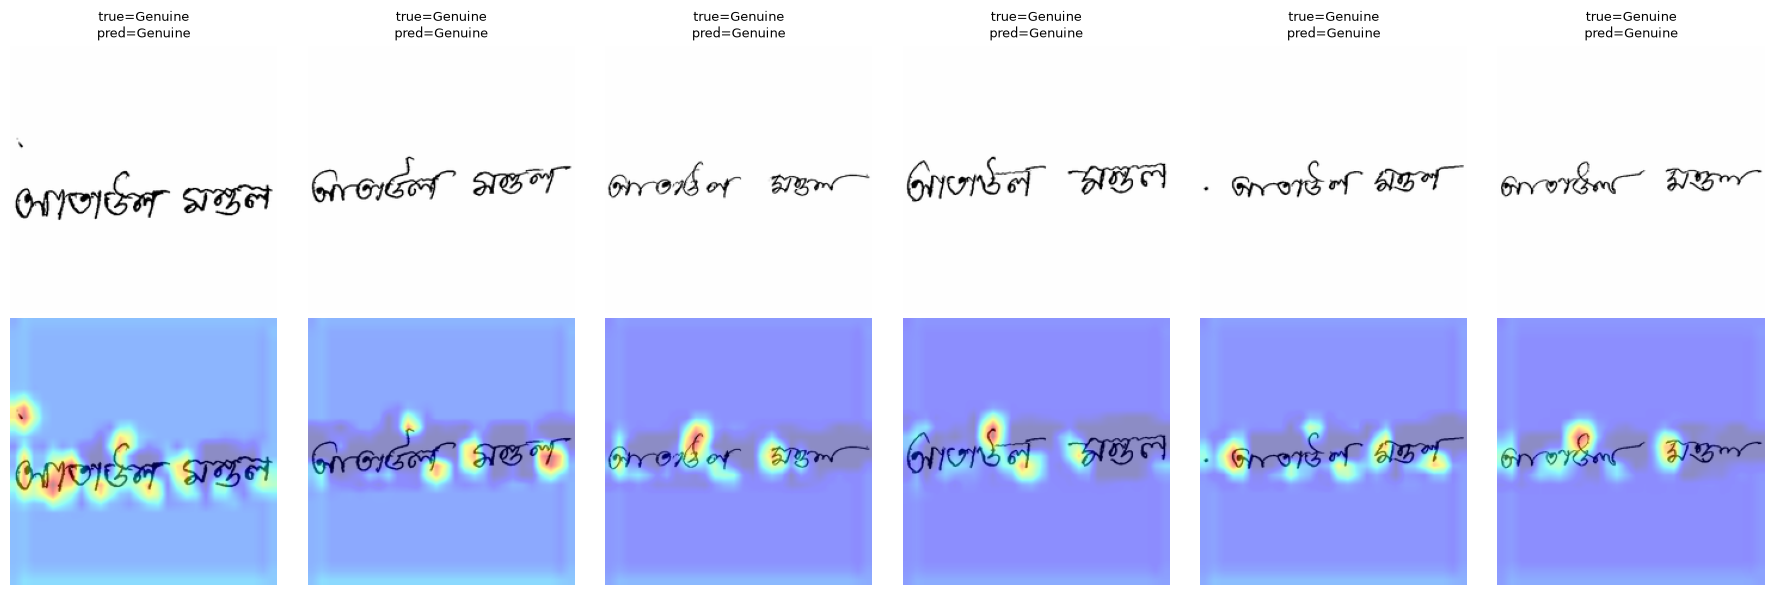

In [19]:
def show_gradcam(dataset, indices, gradcam, mean=NORM_MEAN, std=NORM_STD):
    fig, axes = plt.subplots(2, len(indices), figsize=(3 * len(indices), 6))
    mean_arr, std_arr = np.array(mean), np.array(std)
    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(DEVICE)
        cam, pred_class = gradcam(input_tensor)

        img_np = img_tensor.cpu().numpy().transpose(1, 2, 0)
        img_np = np.clip(img_np * std_arr + mean_arr, 0, 1)

        axes[0, i].imshow(img_np)
        axes[0, i].set_title(f"true={'AI' if label else 'Genuine'}\npred={'AI' if pred_class else 'Genuine'}",
                              fontsize=9)
        axes[0, i].axis("off")

        axes[1, i].imshow(img_np)
        axes[1, i].imshow(cam, cmap="jet", alpha=0.45)
        axes[1, i].axis("off")
    plt.tight_layout()
    plt.show()


sample_indices = list(range(min(6, len(test_ds))))
show_gradcam(test_ds, sample_indices, gradcam)


### Reading the Grad-CAM output
Look at whether attention concentrates on signature-relevant structure — stroke endings,
curves, intersections, dense stroke regions, edge detail — versus diffuse attention over
background or padding, which would suggest the model is picking up on preprocessing
artifacts rather than genuine handwriting characteristics.

## 9. Final model comparison summary

In [20]:
print("=== Overall test-set metrics (Experiment 1: Human vs. all AI; Experiment 6: model comparison) ===")
display(results_df.round(4))

print("\n=== Best model by F1-score ===")
print(f"{best_model_name}: {results_df.loc[best_model_name].to_dict()}")

results_df.round(4).to_csv(RESULTS_DIR / "metrics_overall.csv")
for name, gen_df in generator_results.items():
    gen_df.round(4).to_csv(RESULTS_DIR / f"metrics_by_generator_{name}.csv", index=False)

print(f"\nSaved overall summary to {RESULTS_DIR / 'metrics_overall.csv'}")
print(f"Saved per-generator summaries to {RESULTS_DIR}/metrics_by_generator_<model>.csv")


=== Overall test-set metrics (Experiment 1: Human vs. all AI; Experiment 6: model comparison) ===


,accuracy,precision,recall,f1,roc_auc,human_recall,ai_recall
model,,,,,,,
custom_cnn,0.9698,0.9821,0.9483,0.9649,0.9968,0.9866,0.9483
resnet18,0.9321,0.8657,1.0000,0.9280,0.9981,0.8792,1.0000
efficientnet_b0,0.9057,0.8321,0.9828,0.9012,0.9844,0.8456,0.9828



=== Best model by F1-score ===
custom_cnn: {'accuracy': 0.969811320754717, 'precision': 0.9821428571428571, 'recall': 0.9482758620689655, 'f1': 0.9649122807017544, 'roc_auc': 0.996817866234668, 'human_recall': 0.9865771812080537, 'ai_recall': 0.9482758620689655}

Saved overall summary to ..\results\metrics_overall.csv
Saved per-generator summaries to ..\results/metrics_by_generator_<model>.csv


## Next steps

- As more AI-generated samples / a new generator are added to the dataset, re-run Notebook
  02's splitting step and re-run Section 7's cross-generator experiment with the new
  generator held out — no code changes needed, it iterates over `GENERATORS_PRESENT`
  automatically.
- If Section 6's per-generator breakdown is uneven, consider generator-balanced sampling or
  generator-specific augmentation during training.
- With a relatively small, writer-split dataset, consider re-running Notebook 02's split with
  a few different `RANDOM_SEED` values and reporting variance across seeds, rather than a
  single train/val/test split, before drawing strong conclusions in the paper.
- Experiment 7 from the master note (secondary evaluation using multimodal LLMs/VLMs — GPT,
  Gemini, Qwen — as zero-shot classifiers on the same test images) is handled separately in
  `06_generator_analysis.ipynb`, since it doesn't involve training a CNN.